In [1]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


**Simulation de l'évolution du marché**

Idée de démarche générale : estimation du taux d'occupation et de temps d'atteinte d'un seuil par méthode de Monte Carlo, généralisable à tous les bâtiments, à une ville, à une région. Simulation de l'évolution à différentes échelles de l'occupation de l'immobilier d'entreprise en France.

Pour ça, il faut :

- Informations sur les parcelles : adresse, code ISO de la ville, nom de la ville, nombre de lots, surface des lots… 
- Informations sur les bâtiments : numéro de l'étage, nombre d'étages, taux d'occupation actuel…
- Informations sur le marché : temps moyen avant occupation d'un lot, par ville, par étage, par surface, temps moyen d'utilisation avant revente, nouvelles constructions…
- Informations sur les négociateurs : nombre de visites avant mandat, processus suivi par les visites, simulation d'un processus de vente…
- Informations sur les entreprises : probabilité instantanée de faillite, distribution de la taille des locaux demandée…

Manière de faire : regroupement des lots par clustering ? Régression supervisée ? Estimation des probas par EMV, données INSEE ou historiques de la BDD. Trouver le processus de Poisson de la localisation des locaux sur le territoire, prévision des lieux de construction des nouveaux (simulation de séismes) ?

Forme finale : carte localisation des bâtiments disposant d'offres, avec ajout d'une autre couleur des éventuels nouveaux bâtiments, indicateurs sur les simulations de processus de vente (probas de passage à l'étape suivante), distribution spatiale du taux d'occupation espéré par horizon de temps, indication du temps d'atteinte estimé pour un taux donné d'occupation (inférieur ou supérieur au taux actuel) (statistique de marché)

Possibilité d'envoyer les données sur Superset ? Le tableau de donné à générer serait sur python en local et de taille conséquente, mais pourrait permettre de mieux visualiser dans l'espace les résultats. 

Problème maintenant : trouver les données !

In [2]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

Précisions sur la démarche : 

Comme dans les modèles macroéconomiques microfondés, on part du plus bas niveau pour en déduire le comportement global du marché : les négociateurs, de par leurs caractéristiques observées, vont nous permettre de déduire le comportement espéré des prochains négociateurs qui pourront entrer sur le marché, anticiper les dates de sorties des autres, leur attribuer un comportement spécifique, une zone géographique définie, etc. 

Voici les étapes : 

Entrée des négociateurs et simulation des comportements. Un nouveau négociateur entre sur le marché pour une quelconque raison : explosion du nombre d'offres dans un espace donné à cause de nouvelles constructions, par exemple, ce qui mène une agence à recruter. A partir de là, il faut lui définir un profil : on le fait entrer dans une agence, qui soit existe déjà, soit le négociateur crée son agence. On lui attribue un comportement selon la distribution estimée des comportements des négociateurs que l'on connaît déjà : quantité de lots qu'il gèrera en simultané, superficie et prix des offres qu'il commercialisera, probabilité qu'il parvienne à chaque étape de la commercialisation à passer à la suivante, etc. 

Entrée de nouvelles offres et simulation de nouvelles constructions. Un nouveau bâtiment est créé. Il entre sur le marché côté offres, une agence s'en saisit, et en fonction de la taille de ce nouveau bâtiment, un ou plusieurs négociateurs se partagent le gâteau, ils se retrouvent donc avec un certain nombre de nouvelles offres et donc de nouveaux lots à pourvoir. On commencera par une projection prophet du nombre de nouvelles constructions à attendre par zone géographique dans les prochains mois. Pour la quantité d'offres et de lots qui seront à offrir dans ce nouveau bâtiment, on les simulera selon la distribution empirique de la taille des nouveaux bâtiments construits, puis, si trop de nouveaux lots sont à prendre en charge par rapport aux habitudes des négociateurs des environs, de nouvelles agences pourront voir le jour, ou de nouveaux négociateurs seront embauchés. 

Comportement des entreprises. Elles peuvent soit changer de bureaux, soit venir d'être créées. Dans le premier cas, on peut estimer la distribution de la nouvelle taille demandée à partir de la taille précédente, en utilisant une distribution empirique avec comme paramètre la taille des locaux précédemment occupés. Les locaux nouvellement disponibles reviendront alors sur le marché des offres, générant ainsi de nouveaux lots à pourvoir, et alimentant par la même occasion le stock d'offres des négociateurs. Dans le deuxième cas, l'entreprise nouvellement créée recherchera des petits locaux, et avec une certaine probabilité, un entrepôt pour aller avec. Dans tous les cas, pour choisir son nouveau fief, l'entreprise se questionnera sur le meilleur endroit, la meilleure disposition des locaux, et effectuera plusieurs visites, avec plusieurs négociateurs, le tout sous contrainte de rester en deça d'une certaine distance maximale acceptable au lieu de résidence des collaborateurs. Ce processus de décision, visites, puis déménagement ou emménagement effectif se fera sur plusieurs mois. Il sera facilité si peu de négociateurs et de locaux sont disponibles dans les environs, et donnera l'embarras (le mot est bien choisi) du choix à l'entreprise si de nombreux locaux sont disponibles dans les environs et que de nombreux négociateurs s'arrachent le contrat. Possibilité d'estimation du nombre de visites par une entreprise avant de se décider en régressant cette quantité sur la distance moyenne aux bureaux, le nombre d'offres disponibles dans ce rayon, et le nombre de négociateurs actifs dans ce rayon.

Génération des demandes. En se mettant à rechercher des locaux, les entreprises consultent les sites des agences immobilières alentours et ainsi génèrent un nombre aléatoire de demandes dépendant du nombre d'agences à proximité, du nombre d'offres disponibles dans chacune des agences qu'elles consulteront successivement, et des spécificités des besoins de l'entreprise. Ces dernières seront : bureaux, commerces, restaurants ? Surface recherchée ? Rez-de-chaussée obligatoire (à relier au type d'activité de l'entreprise) ?

Processus de négociation sous-jacent. Création d'une demande pour une agence. Un des négociateurs s'en saisit, celui qui est le plus rapproché en proportion de ses habitues de gestion en ce qui concerne le nombre de demandes à gérer. Le négociateur propose un nombre aléatoire d'offres à son client, dont la loi dépend de ses habitudes. Si l'entreprise trouve chaussure à son pied parmi ces offres, le négociateur organise une visite, qui a ensuite une certaine probabilité d'aboutir, dont ce dernier paramètre de Bernoulli dépend du caractère du négociateur. Une fois signé, le montant de la transaction est versé au négociateur (pour simplifier les choses, car en l'état on ne peut pas savoir quels groupe ont de l'argent d'avance ou non, et donc on ne peut pas estimer les quels seraient enclins à embaucher et lesquels seraient les plus motivés à adopter une stratégie agressive pour obtenir les contrats). 

Le modèle fonctionnerait en temps discret, par périodes d'une semaine, et on réajuste l'état du marché à chacune d'entre elles. Il s'agit d'une sorte de marche aléatoire d'entreprises sur l'ensemble des bureaux localement présents, dont la loi de chaque mouvement est compliquée à estimer au vu de la quantité d'acteurs qui entrent en jeu, et de caractéristiques aléatoires de ces derniers. L'état futur attendu s'estimera au plus simple, par méthode de Monte Carlo.

Quantités à estimer : Quels sont les lieux où une forte activité est à prévoir ?  Quel est le taux de vacance attendu par zone géographique ? Le modèle rend-il bien compte de l'état actuel du marché ? Est-on proche ou éloigné d'un état stationnaire ? Le marché présente-t-il des caractéristiques cycliques, ou une croissance régulière ? A quel point l'occurence de chocs est-elle probable ? De nouveaux concurrents sont-ils susceptibles d'émerger ? Où sont les opportunités ? Quels concurrents empiettent le plus sur le potentiel de croissance d'une agence ?

Forme finale du rendu encore à réfléchir...

In [3]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [ ]:
# Les requêtes : 

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id,
    o.negociateur_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_offre o ON o.offre_id = tj.offre_id
WHERE l.lot_actif = 1
"""

requete_lots_loyer = """
SELECT 
    tj.lot_id,
    tj.ol_actif,
    tj.offre_id,
    tj.ol_loyer
FROM dbo.tj_offre_lot tj
WHERE tj.ol_actif = 1
"""

requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
WHERE l.lot_actif = 1
"""

requete_lots_codes_insee = """
SELECT 
    tj.lot_id,
    ci.code_insee_id,
    ci.ci_code_postal,
    ci.ci_code_insee,
    ci.ci_ville
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
JOIN dbo.tr_code_insee ci ON a.code_insee_id = ci.code_insee_id
WHERE ci.pays_id = 28
"""

requete_demandes = """
SELECT
    demande_id,
    dem_actif,
    dem_surface_minimum,
    dem_surface_maximum,
    dem_budget_minimum,
    dem_budget_maximum,
    dem_recherche_cp,
    dem_date_creation,
    dem_date_archive
FROM dbo.t_demande
WHERE dem_actif = 1
"""

requete_duree_de_vie_negos = """
-- Requête qui permettra de trouver la distribution de la durée de vie empirique des négociateurs
-- ainsi que le processus suivi par leur date d'arrivée sur le marché.
-- Le groupe dans lequel ils arrivent, on s'en fiche comme la simulation doit se faire à l'échelle globale
-- A la limite, peut-être le faire entrer en jeu plus tard pcq le groupe d'appartenance peut avoir
-- une influence sur la durée de vie du négociateur

SELECT
    negociateur_id,
    neg_nom,
    neg_prenom,
    neg_date_creation,
    neg_date_archive,
    neg_actif
FROM dbo.t_negociateur
WHERE neg_actif = 1
"""

requete_gestion_de_lots_negociateurs = """
-- Requête comptage du nombre de lots qui ont été un jour en contact avec chaque négociateur
-- Pour trouver la distribution de l'"efficacité" des négociateurs

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    COUNT(DISTINCT tj.lot_id) AS nombre_lots_associes
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_offre o
    ON o.negociateur_id = n.negociateur_id
LEFT JOIN dbo.tj_offre_lot tj
    ON tj.offre_id = o.offre_id
    WHERE n.neg_actif = 1
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif
HAVING COUNT(DISTINCT tj.lot_id) != 0
"""

requete_transactions_revenus_negociateurs =""" 
-- Maintenant, requête qui va chercher le nombre de transactions qu'ont fait chaque négociateur, 
-- et les revenus que ça a rapporté. Le but est de trouver leur spécialisation sur la base des recettes 
-- par transaction, mais aussi de comparer la quantité de lots avec lesquels ils ont été en contact
-- avec la quantité de transactions dans lesquelles ils vont être impliqués par la suite

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id,
    COUNT(t.transaction_id) AS nombre_transactions,
    SUM(t.tra_loyer) AS montant_total_transactions
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_transaction t
    ON t.negociateur_id = n.negociateur_id
WHERE n.neg_actif = 1
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id
HAVING COUNT(t.transaction_id) > 0
"""

requete_negociateurs_mandats = """ 
-- On relie maintenant les négociateurs à leurs mandats

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    m.mandat_id,
    m.mandat_type_id,
    m.man_date_creation,
    m.man_date_debut,
    m.man_date_fin,
    m.man_date_archive,
    m.man_actif
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_mandat m
    ON m.negociateur_id = n.negociateur_id
WHERE m.man_actif = 1
"""

requete_agences_negociateurs = """ 
-- On relie les négociateurs à leurs agences respectives
-- Ce sera utile pour localiser les négociateurs et leur attribuer les lots qu'ils gèreront

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    
    a.agence_id,
    a.age_nom AS agence_nom,
    a.age_ville AS agence_ville,
    a.age_code_postal AS agence_code_postal,
    a.age_adresse as agence_adresse,
    a.age_actif

FROM dbo.t_negociateur n
LEFT JOIN dbo.t_agence a
    ON n.agence_id = a.agence_id
WHERE a.age_actif = 1
"""

# Ici on a remonté toutes les données actives dans LogiPro

In [5]:
lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

lots_loyers = pd.read_sql_query(requete_lots_loyer, conn)
print(lots_loyers.columns)

lots_codes_insee = pd.read_sql_query(requete_lots_codes_insee, conn)
print(lots_codes_insee.columns)

lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

demandes = pd.read_sql_query(requete_demandes, conn)
print(demandes.columns)

duree_de_vie_negos = pd.read_sql_query(requete_duree_de_vie_negos, conn)
print(duree_de_vie_negos.columns)

gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)
print(gestion_de_lots_negociateurs.columns)

transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
print(transactions_revenus_negociateurs.columns)

negociateurs_mandats = pd.read_sql_query(requete_negociateurs_mandats, conn)
print(negociateurs_mandats.columns)

agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)
print(agences_negociateurs.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_36076\4117252047.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_36076\4117252047.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_loyers = pd.read_sql_query(requete_lots_loyer, conn)


Index(['lot_id', 'ol_actif', 'offre_id', 'ol_loyer'], dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_36076\4117252047.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_codes_insee = pd.read_sql_query(requete_lots_codes_insee, conn)


...

Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif',
       'nombre_lots_associes'],
      dtype='object')
Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'groupe_id',
       'agence_id', 'nombre_transactions', 'montant_total_transactions'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_36076\4117252047.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
C:\Users\quent\AppData\Local\Temp\ipykernel_36076\4117252047.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  negociateurs_mandats = pd.read_sql_query(requete_negociateurs_mandats, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'mandat_id',
       'mandat_type_id', 'man_date_creation', 'man_date_debut', 'man_date_fin',
       'man_date_archive', 'man_actif'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_36076\4117252047.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'agence_id',
       'agence_nom', 'agence_ville', 'agence_code_postal', 'agence_adresse',
       'age_actif'],
      dtype='object')


In [6]:
conn.commit()
cursor.close()
conn.close()

**Première estimation : densité empirique du temps d'activité des négociateurs**

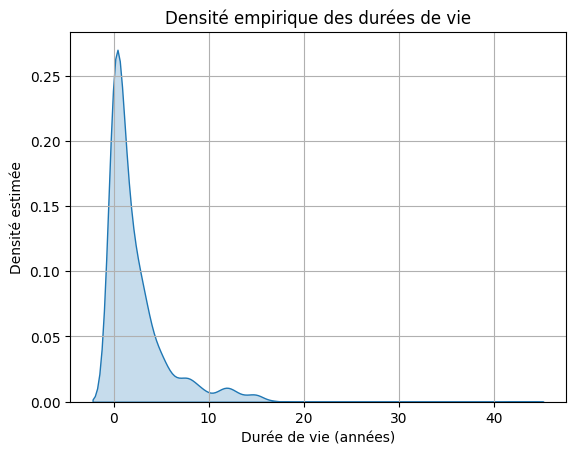

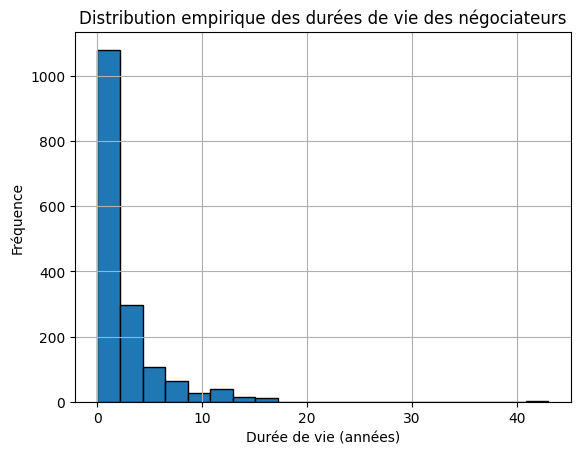

Min : 0.0027378507871321013
Max : 43.0
Moyenne : 2.2698659576548517
Médiane : 1.0787132101300478
Écart-type : 3.248777281439065


In [7]:
duree_de_vie_negos["duree_de_vie"] = duree_de_vie_negos["neg_date_creation"] - duree_de_vie_negos["neg_date_archive"]

liste_duree_de_vie_negos = duree_de_vie_negos["duree_de_vie"].tolist()
liste_duree_de_vie_negos = [x for x in liste_duree_de_vie_negos if x is not NaT]
liste_duree_de_vie_negos = [x for x in liste_duree_de_vie_negos if pd.notna(x) and x != pd.Timedelta(0)]
liste_duree_de_vie_negos = [x.days / 365.25 for x in liste_duree_de_vie_negos]
liste_duree_de_vie_negos = [np.abs(x) for x in liste_duree_de_vie_negos]
liste_duree_de_vie_negos = [x if x < 43 else 43 for x in liste_duree_de_vie_negos]

sns.kdeplot(liste_duree_de_vie_negos, fill=True)
plt.xlabel("Durée de vie (années)")
plt.ylabel("Densité estimée")
plt.title("Densité empirique des durées de vie")
plt.grid(True)
plt.show()

plt.hist(liste_duree_de_vie_negos, bins=20, edgecolor='black')
plt.xlabel("Durée de vie (années)")
plt.ylabel("Fréquence")
plt.title("Distribution empirique des durées de vie des négociateurs")
plt.grid(True)
plt.show()

valeurs = np.array(liste_duree_de_vie_negos)

print("Min :", np.min(valeurs))
print("Max :", np.max(valeurs))
print("Moyenne :", np.mean(valeurs))
print("Médiane :", np.median(valeurs))
print("Écart-type :", np.std(valeurs))

In [8]:
# On supprime ces datasets qui ne pourront donc pas servir

del liste_duree_de_vie_negos
del duree_de_vie_negos
gc.collect()

8007

**Problème : l'échantillon dont on dispose dans la BDD ne représente que le temps que les négociateurs restent inscrits sur LogiPro... En réalité, ce serait très étonnant qu'ils ne restent négociateurs pour la grande majorité qu'un an...**

Aucune étude existante ne donne une distribution de l'ancienneté des négociateurs avant de partir à la retraire ou de changer de métier. 

On n'aura donc aucun moyen de vérifier si les résultats du modèle en termes de longévité des négociateurs dans leur métier représentent bien la réalité. 

**Deuxième estimation : il faut attribuer la probabilité, quand un nouveau négociateur entre sur le marché, qu'il rejoigne une agence déjà existante, ou qu'il fonde sa propre agence**

On peut supposer que plus il y a d'agences actives dans sa région, plus le nouveau négociateur aura tendance à rejoindre une agence existante plutôt que de créer la sienne. 

On suppose une décroissante exponentielle de la probabilité de fonder son agence avec le nombre d'agences existantes. 

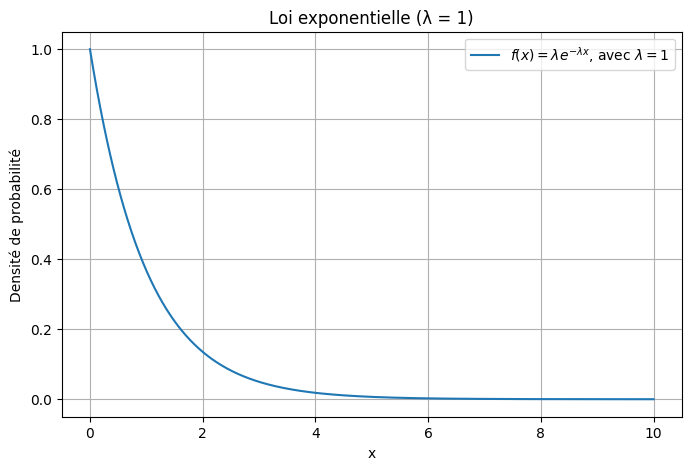

In [9]:
# Paramètre de la loi exponentielle pour qu'on lise en ordonnées la proba de créer une agence et
# en abscisses le nombre d'agences déjà présentes. 
lambda_param = 1

# Génération de valeurs x
x = np.linspace(0, 10, 1000)

# Densité de probabilité (PDF) de la loi exponentielle
pdf = expon.pdf(x, scale=1/lambda_param)

# Tracé du graphe
plt.figure(figsize=(8, 5))
plt.plot(x, pdf, label=r"$f(x) = \lambda e^{-\lambda x}$, avec $\lambda = 1$")
plt.title("Loi exponentielle (λ = 1)")
plt.xlabel("x")
plt.ylabel("Densité de probabilité")
plt.grid(True)
plt.legend()
plt.show()

# Attention, cette loi exponentielle de paramètre 1 pourra par la suite être ajustée car elle ne permet 
# à vrai dire aucune création de nouvelles agences dans les zones dynamiques.
# A voir avec les résultats si on peut conserver cette loi ou l'affiner davantage.

**Une statistique descriptive spatiale bien utile : on représente sur une carte de la France toutes les agences et toutes les offres immobilières**

In [10]:
# # Cellule commentée pcq on l'a exécutée une fois et téléchargé l'excel qui en résulte

# # Extraire les colonnes liées aux agences
# colonnes_agence = ['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse', 'agence_code_postal']

# # Supprimer les doublons pour avoir une ligne par agence unique
# localisations_agences = agences_negociateurs[colonnes_agence].drop_duplicates().reset_index(drop=True)

# print(localisations_agences.columns)
# print(localisations_agences.shape)

# localisations_agences['adresse_complete'] = (
#     localisations_agences['agence_adresse'].astype(str) + ", " +
#     localisations_agences['agence_code_postal'].astype(str) + " " +
#     localisations_agences['agence_ville'].astype(str) + ", France"
# )

# print(localisations_agences.shape)

# # Pour obtenir les coordonnées géographiques des agences, nécessaires à l'affichage d'une carte
# # Compter 10 minutes d'exécution

# geolocator = Nominatim(user_agent="geocodage_agences")

# def geocode_adresse(adresse, retries=3):
#     for attempt in range(retries):
#         try:
#             location = geolocator.geocode(adresse, timeout = 15)
#             if location:
#                 return pd.Series([location.latitude, location.longitude])
#             else:
#                 return pd.Series([None, None])
#         except (GeocoderTimedOut, GeocoderUnavailable) as e:
#             print(f"Essai {attempt+1}/{retries} timeout pour {adresse}, retrying...")
#             time.sleep(2)  # pause avant retry
#         except Exception as e:
#             print(f"Erreur inattendue pour {adresse} : {e}")
#             break
#     return pd.Series([None, None])

# # Appliquer la fonction à chaque ligne
# latitudes = []
# longitudes = []

# i = 0
# for adresse in localisations_agences['adresse_complete'] :
#     i += 1
#     lat, lon = geocode_adresse(adresse)
#     latitudes.append(lat)
#     longitudes.append(lon)
#     print(f"Plus que {localisations_agences.shape[0] - i} coordonnées à caculer")
#     time.sleep(1.3) # Pour éviter d'être bloqué par le service. Si pb de timeout, augmenter le timesleep

# # Ajouter les colonnes au DataFrame
# localisations_agences['latitude'] = latitudes
# localisations_agences['longitude'] = longitudes

# localisations_agences.to_excel("localisations_agences.xlsx", index=False)

# print(localisations_agences.shape)

In [11]:
localisations_agences = pd.read_excel("localisations_agences.xlsx")

In [12]:
gdf_agences = gpd.GeoDataFrame(localisations_agences, geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude), crs="EPSG:4326")
gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# Reprojeter en Web Mercator 
gdf_agences = gdf_agences.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_agences.shape)
print(gdf_offres.shape)

(284, 9)
(2422074, 11)


c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


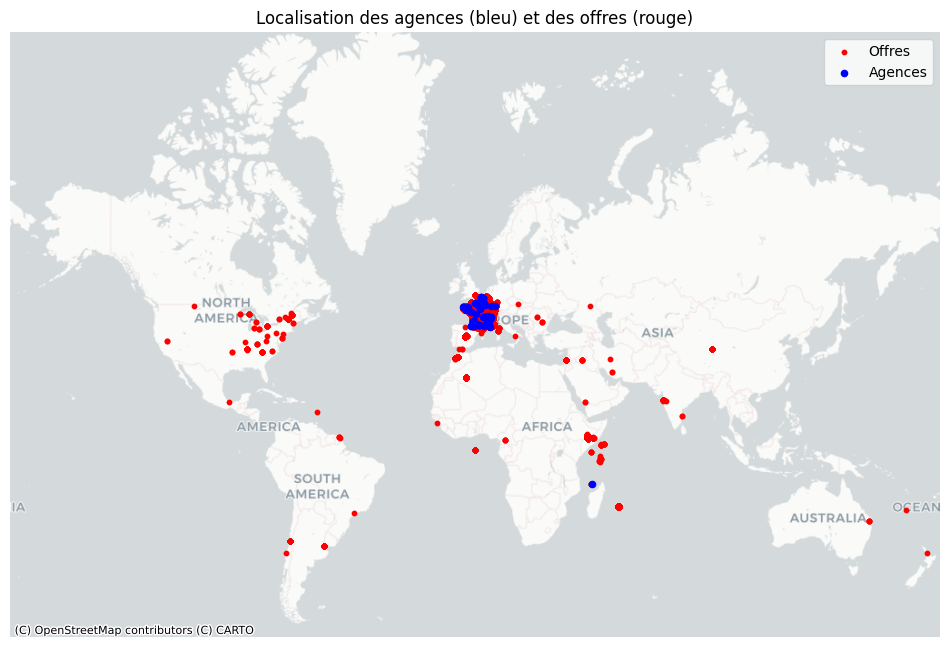

In [13]:
# # Ici on a tous les lots qui sont un jour passés dans LGP. C'est intéressant pour voir la masse totale 
# # du trafic sur les dernières années, mais si on souhaite faire une anbalyse actuelle, c'est fortement biaisé
# # par la croissance de LGP d'une part, mais aussi parce qu'on n'a pas de vue en t de l'état du marché à 
# # un moment "normal". On commente donc ici pour s'économiser du temps.

# fig, ax = plt.subplots(figsize=(12, 12))

# gdf_offres.plot(ax=ax, color='red', markersize=10, label='Offres')
# gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences')

# ax.set_xlim(-20037508, 20037508)
# ax.set_ylim(-8037508, 18037508)

# # Ajouter le fond de carte
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# plt.legend()
# ax.set_axis_off()

# plt.title("Localisation des agences (bleu) et des offres (rouge)")
# plt.show()

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


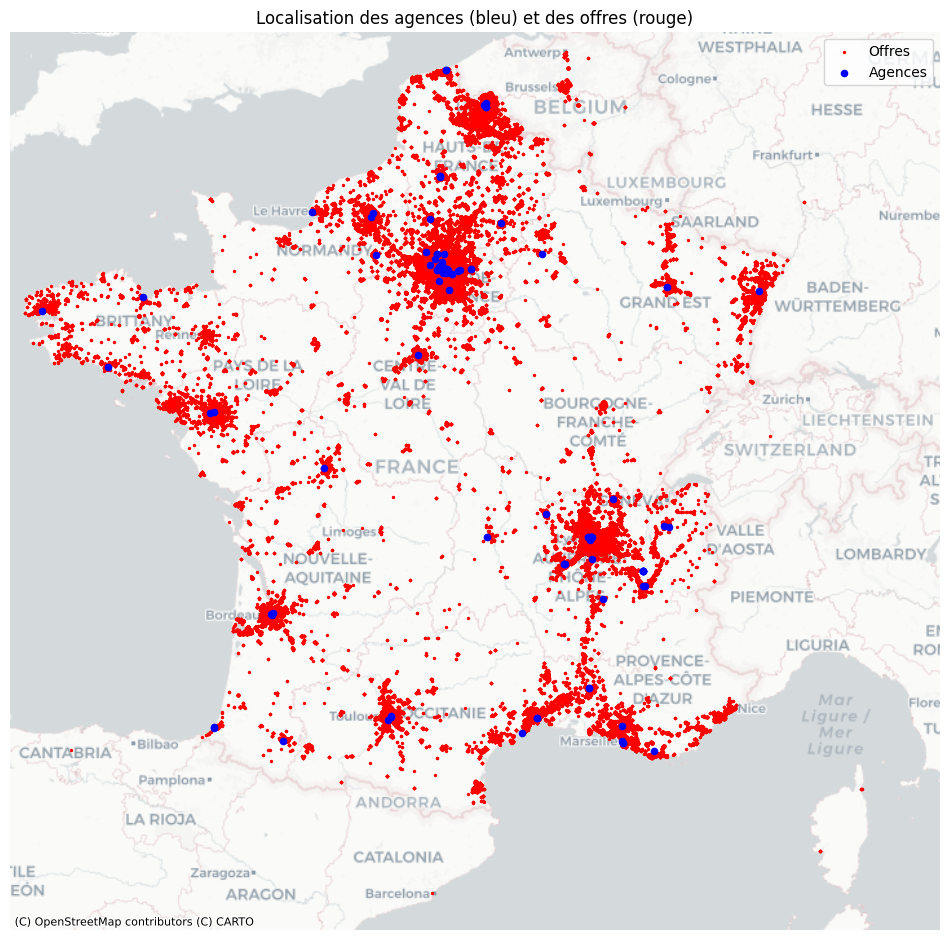

In [14]:
# # Ici on a tous les lots qui sont un jour passés dans LGP. C'est intéressant pour voir la masse totale 
# # du trafic sur les dernières années, mais si on souhaite faire une anbalyse actuelle, c'est fortement biaisé
# # par la croissance de LGP d'une part, mais aussi parce qu'on n'a pas de vue en t de l'état du marché à 
# # un moment "normal". On commente donc ici pour s'économiser du temps.

# fig, ax = plt.subplots(figsize=(12, 12))

# gdf_offres.plot(ax=ax, color='red', markersize=2, label='Offres')
# gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences')

# # Définir les limites France métropolitaine
# # Limites France métropolitaine en EPSG:3857
# ax.set_xlim(-560000, 1200000)
# ax.set_ylim(5000000, 6700000)

# # Ajouter le fond de carte
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# plt.legend()
# ax.set_axis_off()
# plt.title("Localisation des agences (bleu) et des offres (rouge)")
# plt.show()

**Attention, ces deux cartes précédentes montrent toutes les agences et toutes les offres qui ont un jour été actives. On affiche ci-dessous l'état actuel du marché** (sur l'échantillon LGP)

In [15]:
# Supprimer la colonne si elle existe déjà
if 'age_actif' in gdf_agences.columns :
    gdf_agences.drop(columns='age_actif', inplace=True)
if 'age_actif_x' in gdf_agences.columns :
    gdf_agences.drop(columns='age_actif_x', inplace=True)
if 'age_actif_y' in gdf_agences.columns :
    gdf_agences.drop(columns='age_actif_y', inplace=True)

# Supprimer la colonne si elle existe déjà
if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)
if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

print(gdf_agences.columns)
print(gdf_offres.columns)

Index(['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse',
       'agence_code_postal', 'adresse_complete', 'latitude', 'longitude',
       'geometry'],
      dtype='object')
Index(['lot_id', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id', 'geometry'],
      dtype='object')


In [16]:
agences_actives = (agences_negociateurs.groupby('agence_id', as_index=False)['age_actif'].max())
gdf_agences = gdf_agences.merge(agences_actives, on='agence_id', how='left')

lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

In [17]:
# Filtrage : uniquement les points actifs
gdf_agences = gdf_agences[gdf_agences['age_actif'] == 1]
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]

# Reprojeter en Web Mercator si ce n’est pas déjà fait
gdf_agences = gdf_agences.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_agences.shape)
print(gdf_offres.shape)

(255, 10)
(2422071, 11)


c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


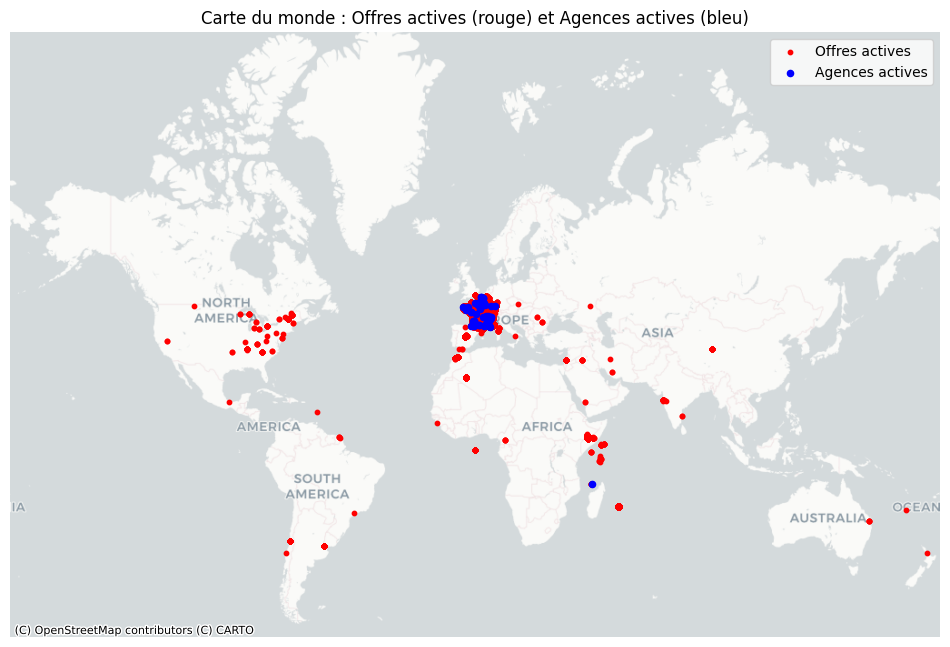

In [18]:
# Carte du monde
fig, ax = plt.subplots(figsize=(12, 12))

gdf_offres.plot(ax=ax, color='red', markersize=10, label='Offres actives')
gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences actives')

ax.set_xlim(-20037508, 20037508)
ax.set_ylim(-8037508, 18037508)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.legend()
ax.set_axis_off()
plt.title("Carte du monde : Offres actives (rouge) et Agences actives (bleu)")
plt.show()


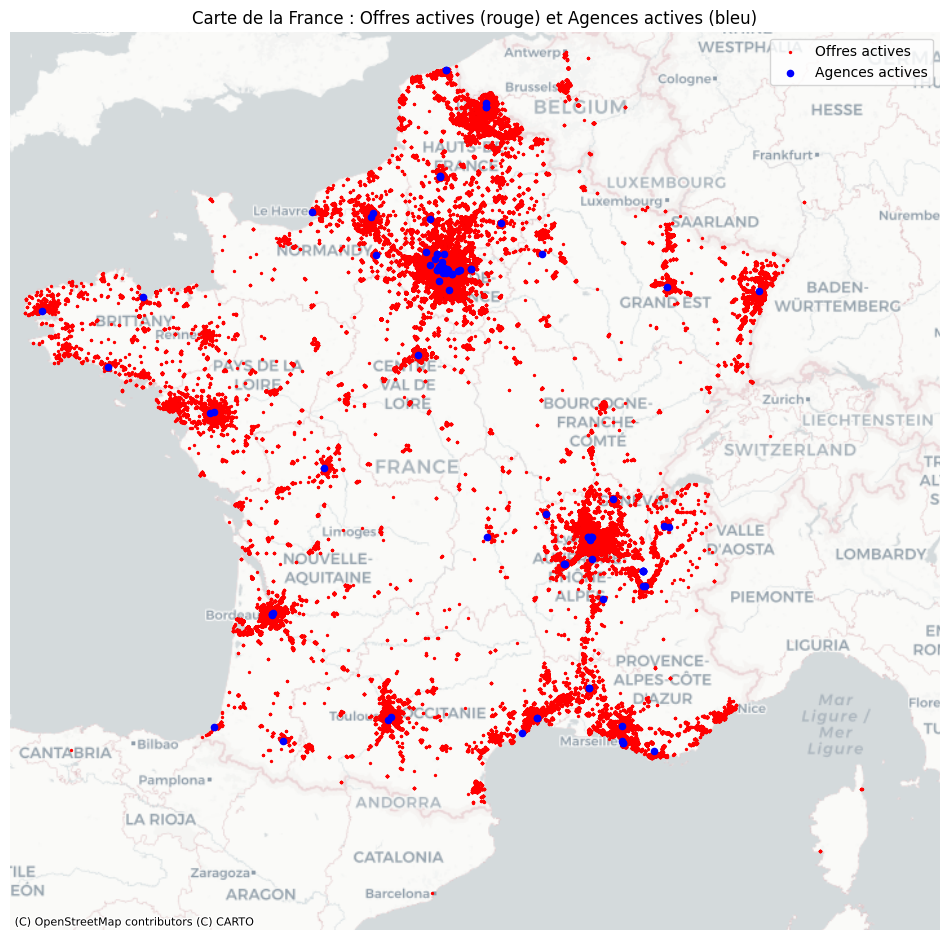

In [19]:
fig, ax = plt.subplots(figsize=(12, 12))

gdf_offres.plot(ax=ax, color='red', markersize=2, label='Offres actives')
gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences actives')

# Zoom sur la France
ax.set_xlim(-560000, 1200000)
ax.set_ylim(5000000, 6700000)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.legend()
ax.set_axis_off()
plt.title("Carte de la France : Offres actives (rouge) et Agences actives (bleu)")
plt.show()

In [20]:
# On ne garde que ce qui est en France
gdf_offres = gdf_offres.cx[-560000:1200000, 5000000:6700000]

# Vérifier les min/max
print(gdf_offres['adr_plan_x'].min(), gdf_offres['adr_plan_x'].max())
print(gdf_offres['adr_plan_y'].min(), gdf_offres['adr_plan_y'].max())

# Vérifier les valeurs manquantes
print(gdf_offres[['adr_plan_x', 'adr_plan_y']].isnull().sum())

-4.77380330000005 9.448236465454102
41.39147524875518 51.2312752
adr_plan_x    0
adr_plan_y    0
dtype: int64


In [ ]:
# # Compter 1h20 d'execution

# # Extraire les coordonnées x, y depuis la géométrie
# coords = np.array([(point.x, point.y) for point in gdf_offres.geometry])

# # Paramètres pour la grille de la heatmap
# x_min, y_min, x_max, y_max = gdf_offres.total_bounds
# grid_size = 1500  
# bandwidth = 15000 

# # Générer la grille
# x_grid = np.arange(x_min, x_max, grid_size)
# y_grid = np.arange(y_min, y_max, grid_size)
# xv, yv = np.meshgrid(x_grid, y_grid)
# grid_coords = np.vstack([xv.ravel(), yv.ravel()]).T

# # Estimation de la densité par noyau
# kde = KernelDensity(bandwidth=bandwidth, metric='euclidean', kernel='gaussian')
# kde.fit(coords)
# log_density = kde.score_samples(grid_coords)
# density = np.exp(log_density).reshape(len(y_grid), len(x_grid))

# # Affichage de la heatmap
# fig, ax = plt.subplots(figsize=(10, 10))
# heatmap = ax.imshow(density, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='Reds', alpha=0.7)

# # Superposer les points originaux
# gdf_offres.plot(ax=ax, markersize=2, color='black', alpha=0.5)

# # Ajouter la légende et les axes
# plt.colorbar(heatmap, ax=ax, label="Densité estimée")
# ax.set_title("Heatmap de densité des lots (KDE)")
# ax.set_xlabel("X (mètres, EPSG:3857)")
# ax.set_ylabel("Y (mètres, EPSG:3857)")
# plt.grid(True)
# plt.show()

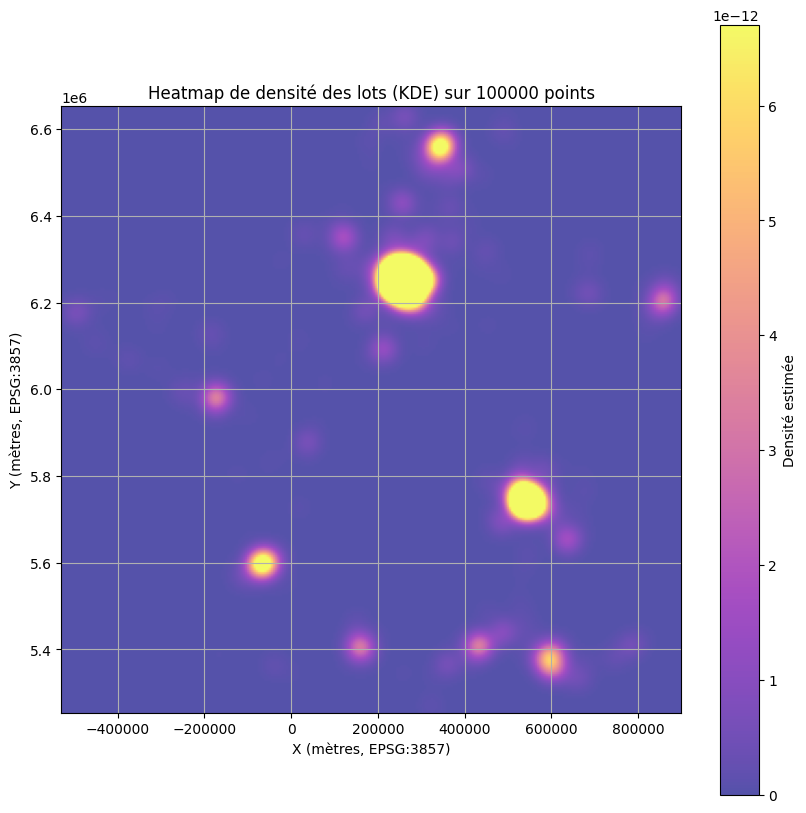

In [33]:
# Tirer un échantillon aléatoire de 1 000 000 points
sample_size = min(100000, len(gdf_offres))
gdf_sample = gdf_offres.sample(sample_size, random_state=42)

# Extraire les coordonnées x, y depuis la géométrie de l'échantillon
coords = np.array([(point.x, point.y) for point in gdf_sample.geometry])

# Paramètres pour la grille de la heatmap
x_min, y_min, x_max, y_max = gdf_sample.total_bounds
grid_size = 5000  # on découpe l'espace en une grille de carrés de x mètres sur x mètres
bandwidth = 20000  # à quelle distance en mètres un point influe sur la densité estimée autour de lui

# Générer la grille
x_grid = np.arange(x_min, x_max, grid_size)
y_grid = np.arange(y_min, y_max, grid_size)
xv, yv = np.meshgrid(x_grid, y_grid)
grid_coords = np.vstack([xv.ravel(), yv.ravel()]).T

# Estimation de la densité par noyau sur l'échantillon
kde = KernelDensity(bandwidth=bandwidth, metric='euclidean', kernel='gaussian')
kde.fit(coords)
log_density = kde.score_samples(grid_coords)
density = np.exp(log_density).reshape(len(y_grid), len(x_grid))
log_density_display = np.log1p(density)  # log(1 + densité) évite les -inf


# Affichage de la heatmap
fig, ax = plt.subplots(figsize=(10, 10))

vmin = np.percentile(log_density_display, 5)   # ou 1
vmax = np.percentile(log_density_display, 99) # ou 99.9

heatmap = ax.imshow(
    log_density_display,
    extent=(x_min, x_max, y_min, y_max),
    origin='lower',
    cmap='plasma',
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

# Pour afficher un point par lot. Chiant, ça cache la densité
# # gdf_sample.plot(ax=ax, markersize=2, color='black', alpha=0.5)

# Ajouter la légende et les axes
plt.colorbar(heatmap, ax=ax, label="Densité estimée")
ax.set_title(f"Heatmap de densité des lots (KDE) sur {sample_size} points")
ax.set_xlabel("X (mètres, EPSG:3857)")
ax.set_ylabel("Y (mètres, EPSG:3857)")
plt.grid(True)
plt.show()

**Maintenant, on va évaluer la loi empirique du nombre d'offres gérées par les négociateurs**

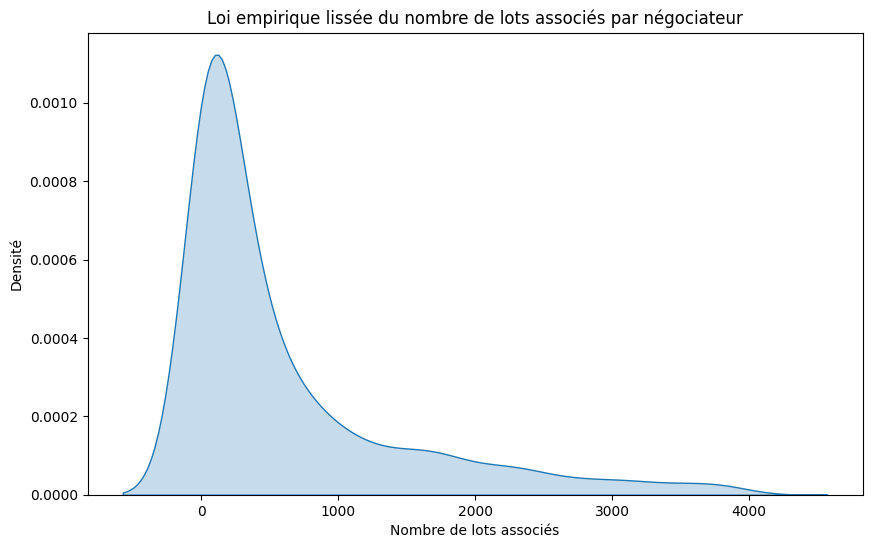

In [ ]:
# On commence par éliminer les outliers

gestion_de_lots_negociateurs = gestion_de_lots_negociateurs[gestion_de_lots_negociateurs["nombre_lots_associes"] < 4000]
gestion_de_lots_negociateurs = gestion_de_lots_negociateurs[gestion_de_lots_negociateurs["nombre_lots_associes"] > 5]

plt.figure(figsize=(10, 6))
sns.kdeplot(data=gestion_de_lots_negociateurs, x='nombre_lots_associes', fill=True, bw_adjust=1)
plt.title("Loi empirique lissée du nombre de lots associés par négociateur")
plt.xlabel("Nombre de lots associés")
plt.ylabel("Densité")
plt.show()

Commentaire sur le fat que la densité déborde dans les négatifs : les lois empiriques lissées sont obtenues à partir de mélanges gaussiens, qui sont donc de lois avec queues infinies... C'est pour cela que la densité déborde dans les négatifs même si toutes les valeurs observées sont positives. On tronque les valeurs générées par la suite selon cette loi.

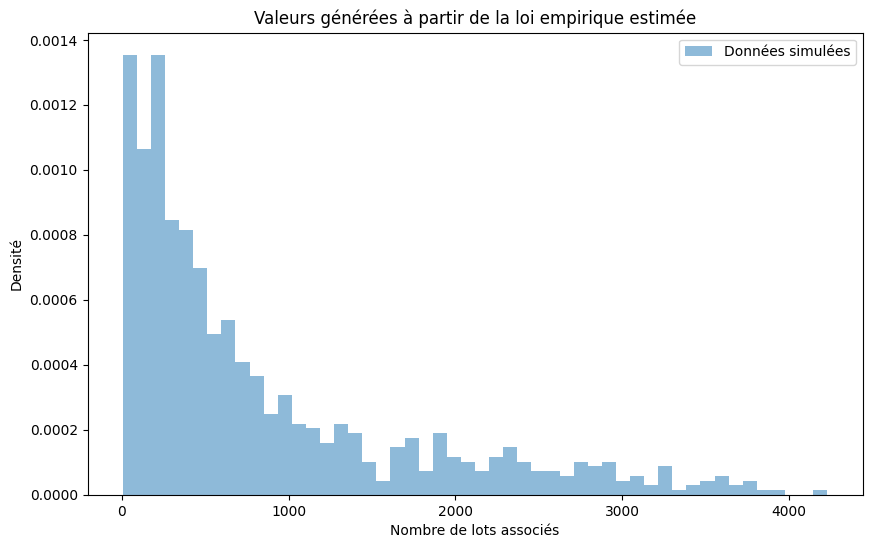

[3172, 257, 932, 283, 314, 199, 250, 2643, 2416, 84, 1094, 1650, 1908, 1950, 360, 1056, 190, 13, 391, 545, 421, 249, 284, 827, 373, 433, 1178, 691, 1857, 229, 12, 66, 707, 182, 658, 2908, 228, 413, 3580, 165, 3057, 48, 1617, 270, 468, 901, 3737, 3791, 204, 773, 193, 972, 597, 1964, 1931, 60, 655, 202, 787, 113, 26, 341, 1385, 276, 489, 104, 2365, 1809, 605, 140, 73, 263, 1234, 785, 575, 111, 537, 957, 86, 479, 476, 1291, 53, 329, 397, 454, 311, 284, 312, 1359, 242, 2284, 176, 278, 6, 238, 263, 373, 809, 32, 670, 830, 383, 247, 2162, 49, 3017, 311, 223, 3072, 1279, 157, 675, 124, 420, 418, 433, 720, 88, 1460, 568, 2063, 265, 1657, 395, 50, 128, 605, 1410, 2757, 383, 951, 134, 2805, 328, 376, 213, 32, 287, 2960, 390, 790, 188, 2444, 570, 52, 688, 2406, 494, 427, 610, 1882, 3029, 328, 391, 8, 1721, 65, 447, 1370, 1870, 974, 997, 1492, 1346, 2303, 208, 3503, 570, 490, 82, 141, 611, 2717, 245, 35, 2389, 3693, 15, 3232, 99, 11, 185, 708, 125, 501, 2065, 2306, 1168, 59, 673, 131, 355, 1235, 2

In [ ]:
kde_nb_lots_negos = gaussian_kde(gestion_de_lots_negociateurs['nombre_lots_associes'].values, bw_method='scott')
valeurs_simulees_nb_lots_negos = np.floor(kde_nb_lots_negos.resample(1000)[0]).astype(int)
valeurs_simulees_nb_lots_negos = [x for x in valeurs_simulees_nb_lots_negos if x > 5]

# Afficher la distribution simulée
plt.figure(figsize=(10, 6))
plt.hist(valeurs_simulees_nb_lots_negos, bins=50, density=True, alpha=0.5, label="Données simulées")
plt.title("Valeurs générées à partir de la loi empirique estimée")
plt.xlabel("Nombre de lots associés")
plt.ylabel("Densité")
plt.legend()
plt.show()

print(valeurs_simulees_nb_lots_negos)

Ca y est, on a le nombre de lots que gèreront les nouveaux négociateurs entrant sur le marché. On pourrait le voir comme le "type" du négociateur : est-ce un négociateur qui gère de grosses offres avec beaucoup de lots ? Est-ce un négociateur qui gère de nombreuses petites offres constituées d'un unique lot ?

**Une autre variable et à prendre en compte : la distribution empirique de la quantité d'argent générée par transaction en moyenne par négociateur. Ce qui aidera à affiner la manière de générer des nouveaux négociateurs.**

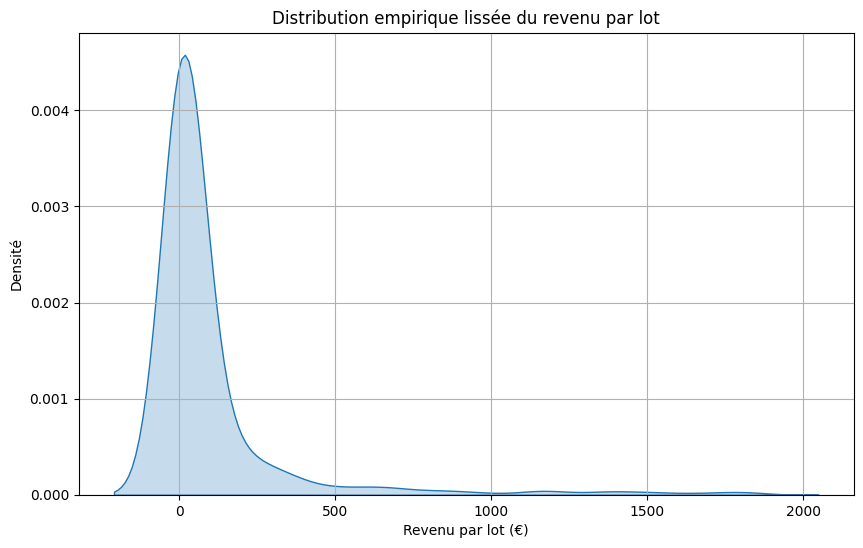

In [ ]:
# Fusionner les deux DataFrames sur negociateur_id
negociateurs_revenus_par_transac = pd.merge(
    gestion_de_lots_negociateurs[['negociateur_id', 'nombre_lots_associes']],
    transactions_revenus_negociateurs[['negociateur_id', 'montant_total_transactions']],
    on='negociateur_id',
    how='inner'
)

# Calcul du ratio : montant total / nombre de lots
negociateurs_revenus_par_transac['revenu_par_lot'] = (negociateurs_revenus_par_transac['montant_total_transactions']/negociateurs_revenus_par_transac['nombre_lots_associes'])

negociateurs_revenus_par_transac = negociateurs_revenus_par_transac[negociateurs_revenus_par_transac["revenu_par_lot"] < 2000]
negociateurs_revenus_par_transac = negociateurs_revenus_par_transac[negociateurs_revenus_par_transac["revenu_par_lot"] > 0]

# Affichage du KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(data=negociateurs_revenus_par_transac, x='revenu_par_lot', fill=True, bw_adjust=1)
plt.title("Distribution empirique lissée du revenu par lot")
plt.xlabel("Revenu par lot (€)")
plt.ylabel("Densité")
plt.grid(True)
plt.show()

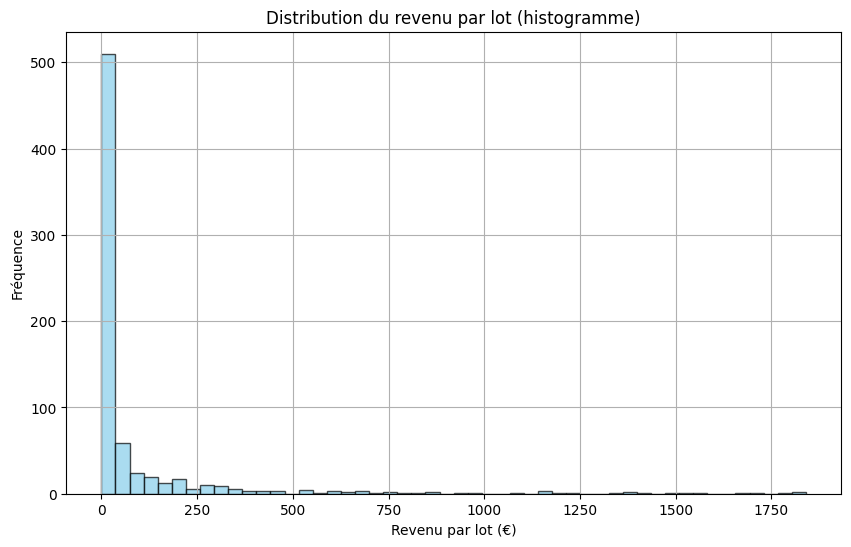

In [ ]:
plt.figure(figsize=(10, 6))

# Histogramme non lissé
plt.hist(
    negociateurs_revenus_par_transac['revenu_par_lot'],
    bins=50,               # Nombre de barres
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.title("Distribution du revenu par lot (histogramme)")
plt.xlabel("Revenu par lot (€)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()